In [19]:
import importlib

import codebase.GossipModel as GossipModel
import codebase.experiments as experiments

importlib.reload(GossipModel)
importlib.reload(experiments)

from codebase.GossipModel import *
from codebase.experiments import *

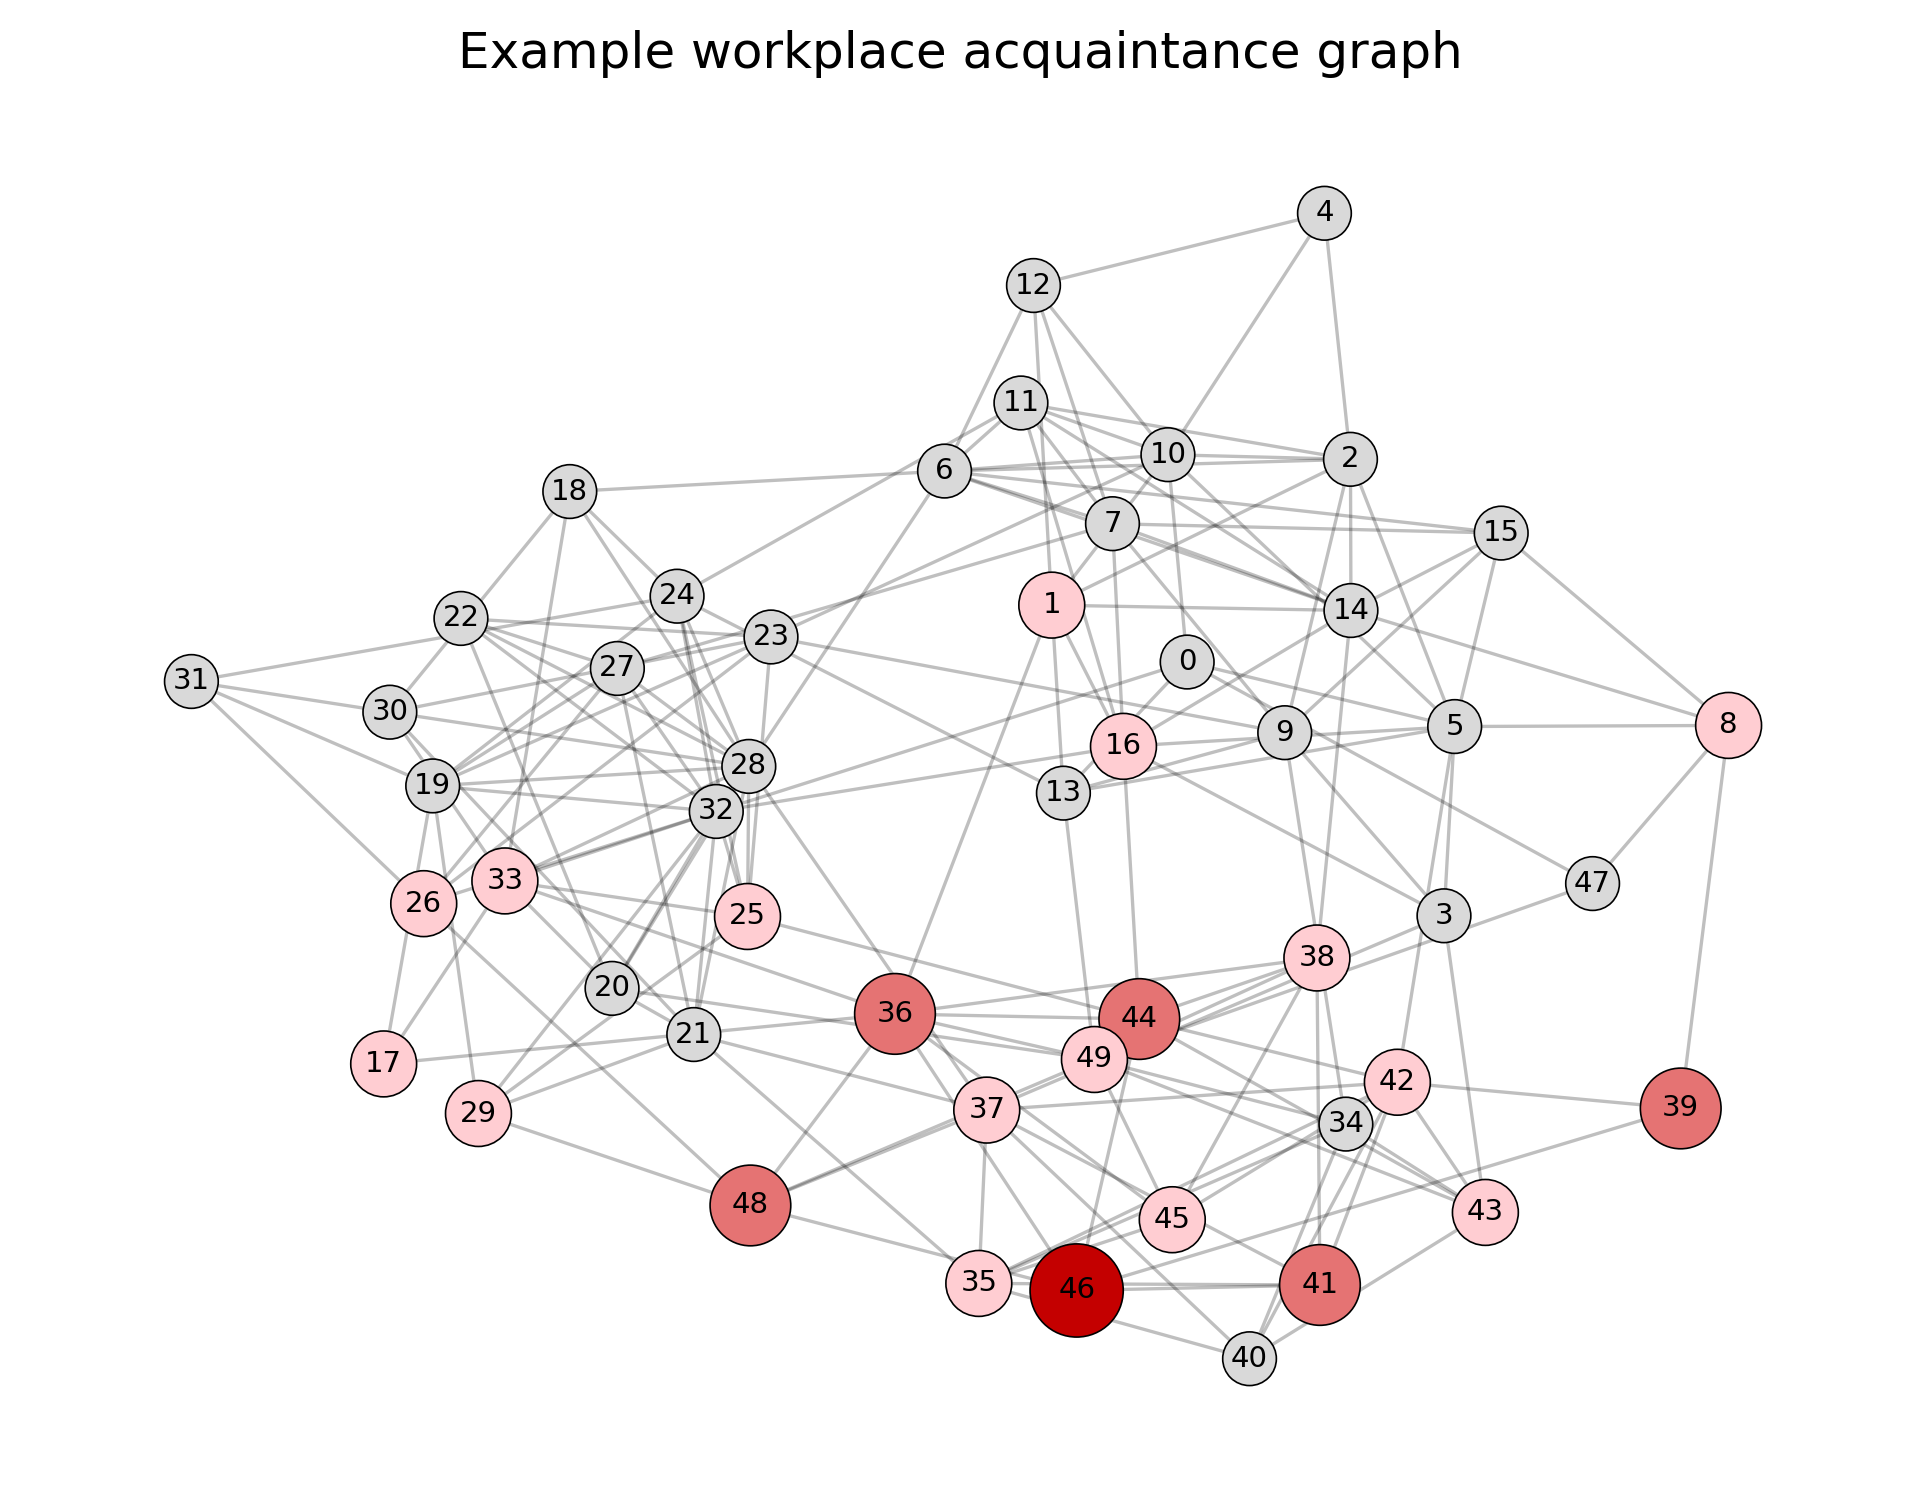

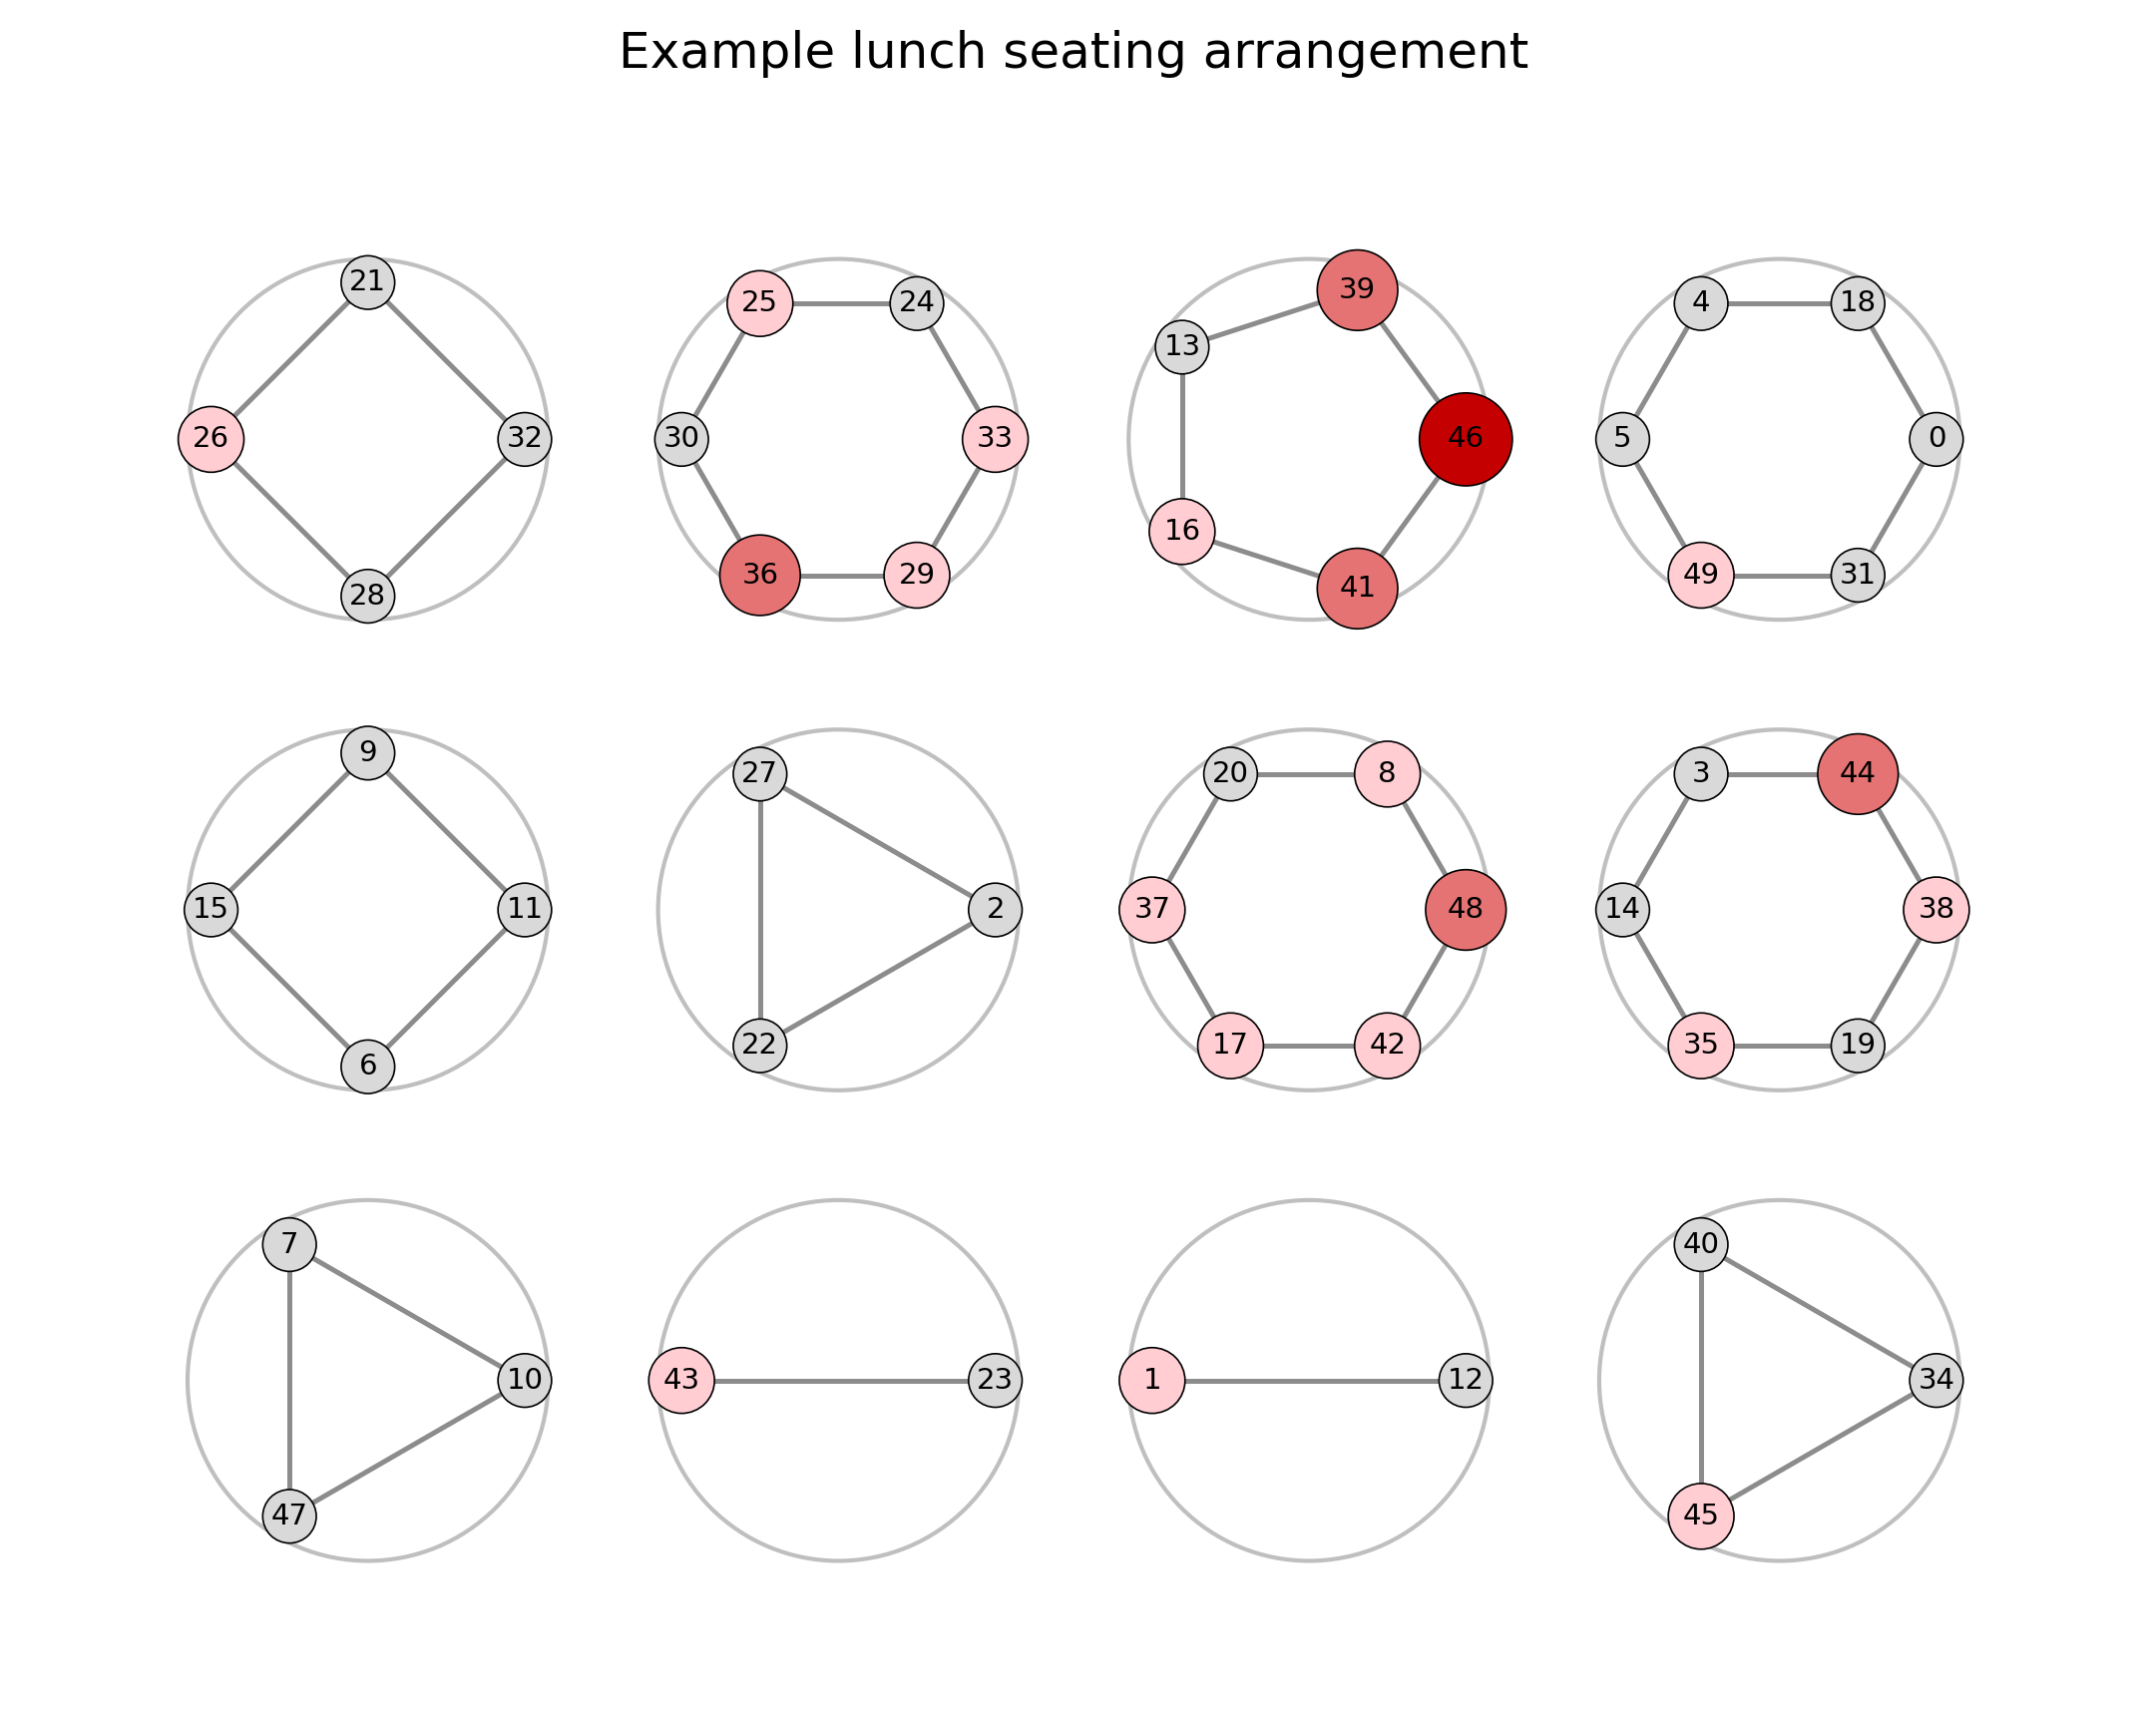

In [3]:
params = LunchGossipParams(
    n_people=50,
    avg_degree=3,
    table_size=6,
    n_tables=12,
    beta=0.30,
    seating_factor=0.25,
    seating_alpha=0.70,
    friend_seating_bias=3.0,
    lunch_attendance_prob=1.0,
    graph_type="sbm",
    n_groups=3,
    p_intra=0.30,
    p_inter=0.03,
    seed=20,
)

model = LunchGossipModel(params)

start_node = model.reset(start_mode="random")

model.plot_friendship_graph(
    layout="kamada_kawai",
    show_labels=True,
    highlight_node=start_node,
    highlight_neighborhood=True,
    title="Example workplace acquaintance graph",
    save_path="./figures/example_acquaintance_graph.pdf",
    base_node_size=500
)

model.simulate_day()

model.plot_current_lunch_tables(
    show_labels=True,
    highlight_node=start_node,
    highlight_neighborhood=True,
    title="Example lunch seating arrangement",
    save_path="./figures/example_lunch_seating.pdf",
    base_node_size=500
)

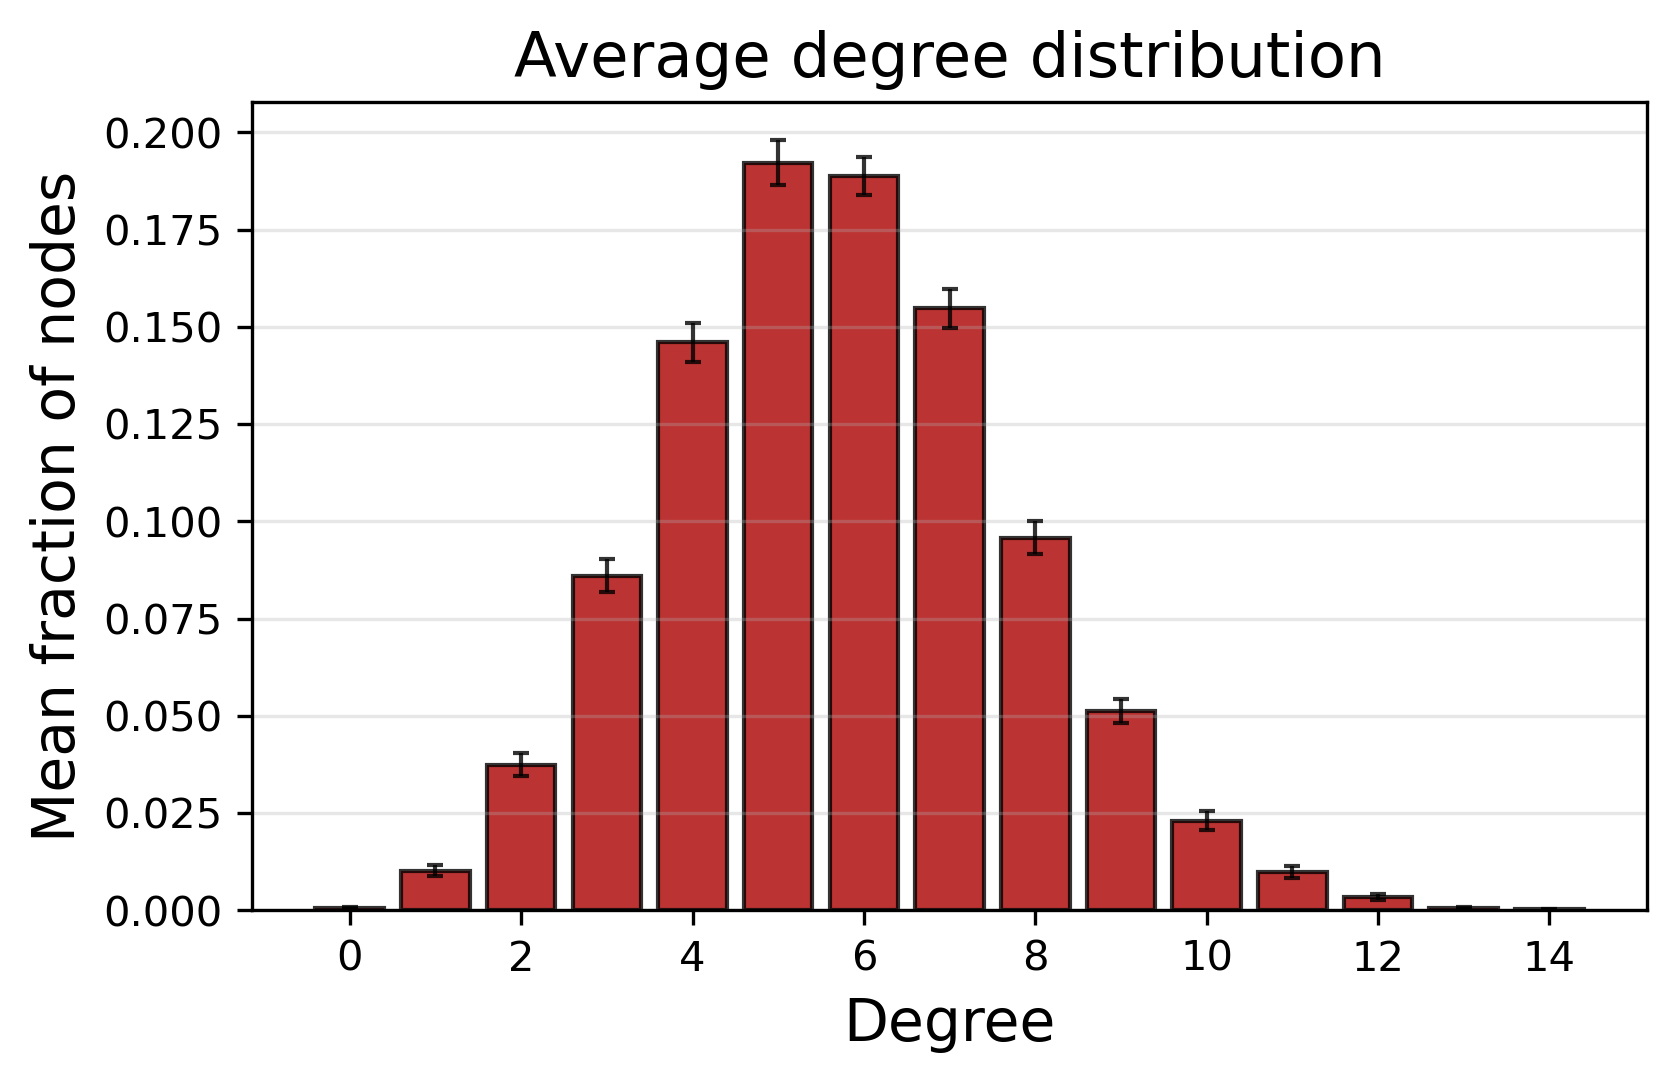

In [10]:
params = LunchGossipParams(
    n_people=50,
    avg_degree=3,
    table_size=6,
    n_tables=12,
    beta=0.30,
    seating_factor=0.25,
    seating_alpha=0.70,
    friend_seating_bias=3.0,
    lunch_attendance_prob=1.0,
    graph_type="sbm",
    n_groups=3,
    p_intra=0.30,
    p_inter=0.03,
    seed=10,
)

degree_runs = run_degree_distribution_ensemble(
    base_params=params,
    n_runs=100,
    seed_start=5000,
)

degree_summary = summarize_degree_distribution_ensemble(degree_runs)

plot_average_degree_distribution(
    degree_summary,
    color="#AB0000",
    show_se_band=True,
    title="Average degree distribution",
    save_path="./figures/average_degree_distribution.pdf",
)

## Comparison of gossip spreading on the static acquaintance graph and in the temporal lunch-contact model

In [20]:
params = LunchGossipParams(
    n_people=50,
    avg_degree=3,
    table_size=6,
    n_tables=12,
    beta=0.30,
    seating_factor=0.25,
    seating_alpha=0.70,
    friend_seating_bias=3.0,
    lunch_attendance_prob=1.0,
    graph_type="sbm",
    n_groups=3,
    p_intra=0.30,
    p_inter=0.03,
    seed=20,
)

histories = run_static_vs_lunch_comparison(
    base_params=params,
    n_runs=100,
    max_days=60,
    start_mode="random",
    include_two_step_static=True,
    seed_start=1000,
)

summary = summarize_spreading_curves(histories)

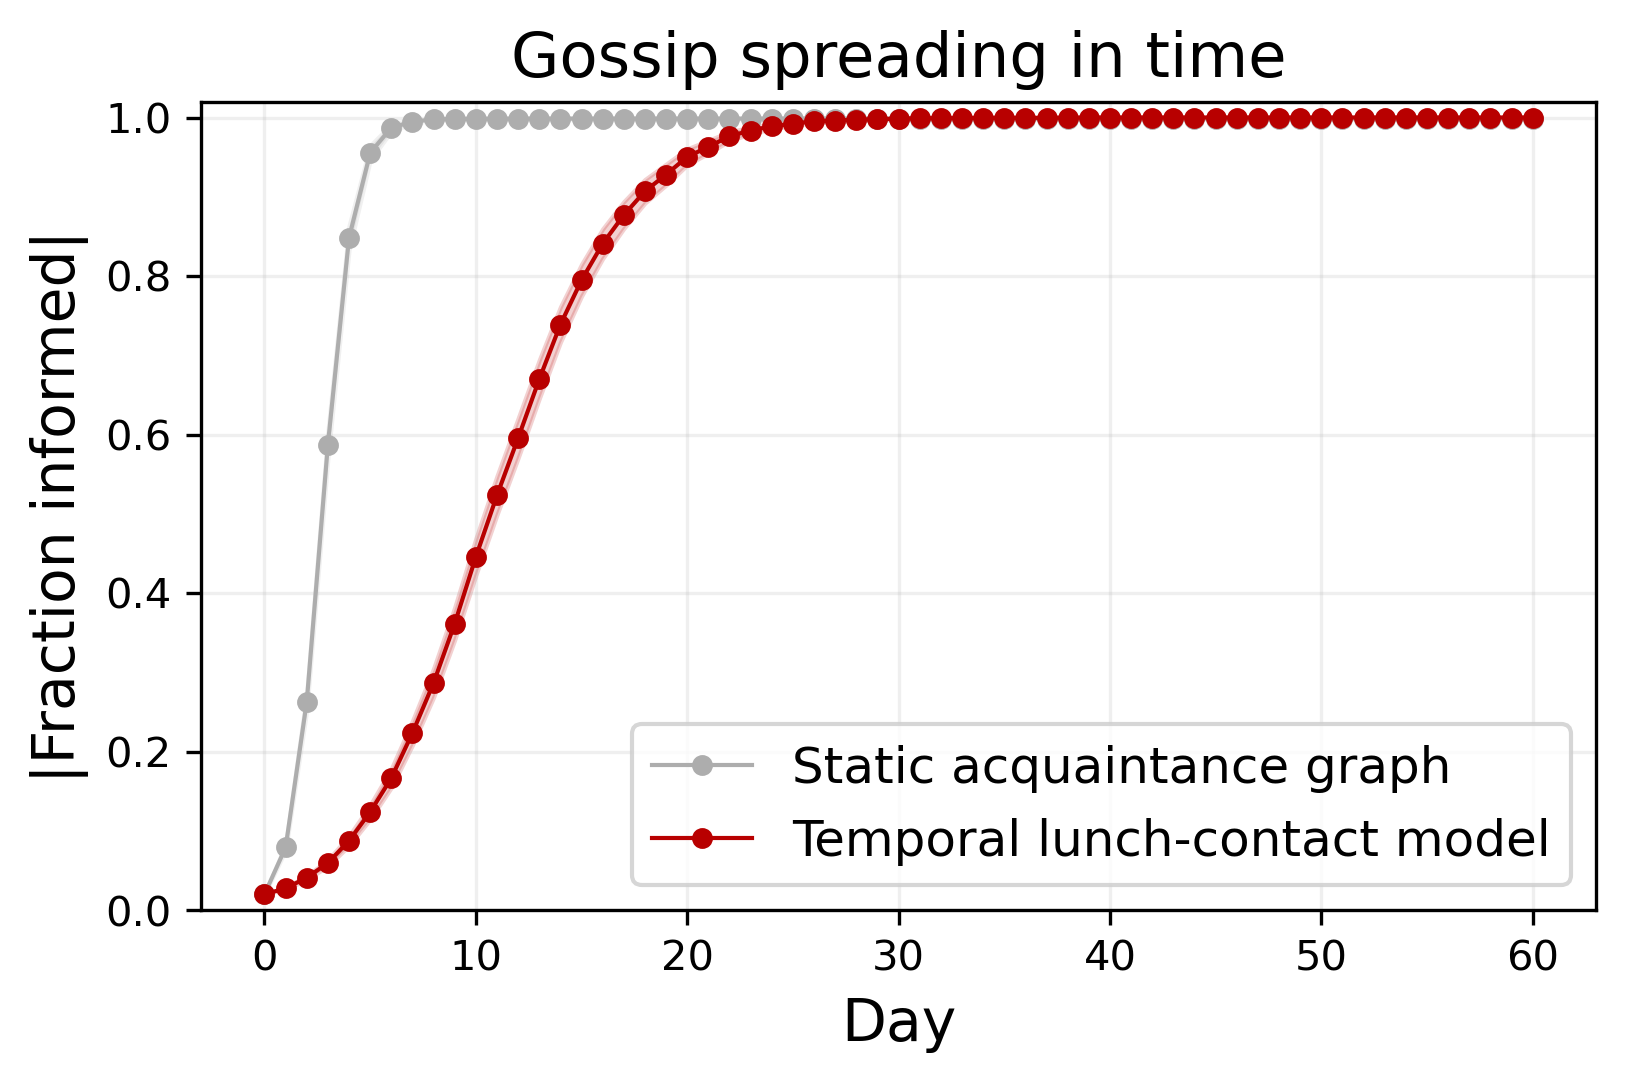

In [21]:
plot_static_vs_lunch_average_curves(
    summary,
    show_se_band=True,
    save_path="./figures/static_vs_lunch_spreading.pdf",
    title="Gossip spreading in time",
    colors={
        "Static acquaintance graph": "#ADADAD",
        "Temporal lunch-contact model": "#B80000",
    },
)

## Effect of source node

In [22]:
params = LunchGossipParams(
    n_people=50,
    avg_degree=3,
    table_size=6,
    n_tables=12,
    beta=0.30,
    seating_factor=0.25,
    seating_alpha=0.70,
    friend_seating_bias=3.0,
    lunch_attendance_prob=1.0,
    graph_type="sbm",
    n_groups=3,
    p_intra=0.30,
    p_inter=0.03,
    seed=20,
)

histories_start, t80_start = run_start_node_comparison(
    base_params=params,
    start_modes=[
        "random",
        "highest_degree",
        "lowest_degree",
        "highest_betweenness",
    ],
    n_runs=100,
    max_days=60,
    threshold=0.8,
    seed_start=2000,
)

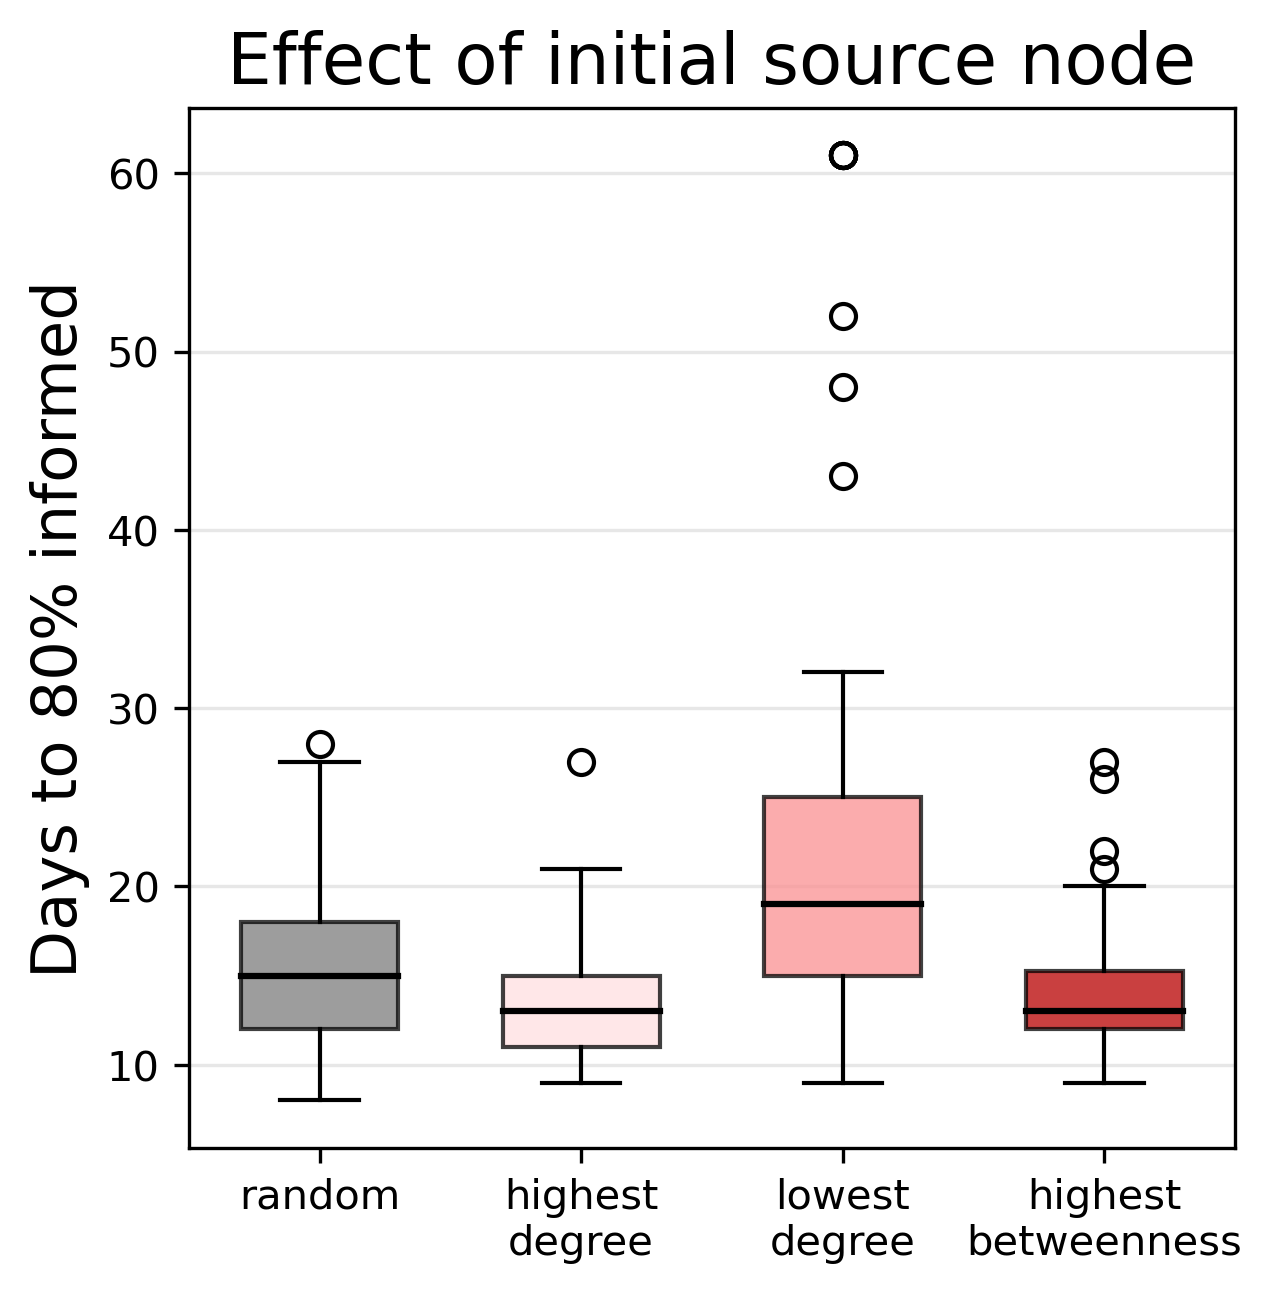

In [23]:
start_mode_colors = {
    "random": "#7D7D7D",
    "highest_degree": "#FFE0E1",
    "lowest_degree": "#FA9092",
    "highest_betweenness": "#B80000",
}

plot_start_node_threshold_boxplot(
    t_thresholds=t80_start, xlabel="",
    threshold=0.8, figsize=(4.5, 4.5),
    colors=start_mode_colors,
    save_path="./figures/start_node_T80_boxplot.pdf",
)

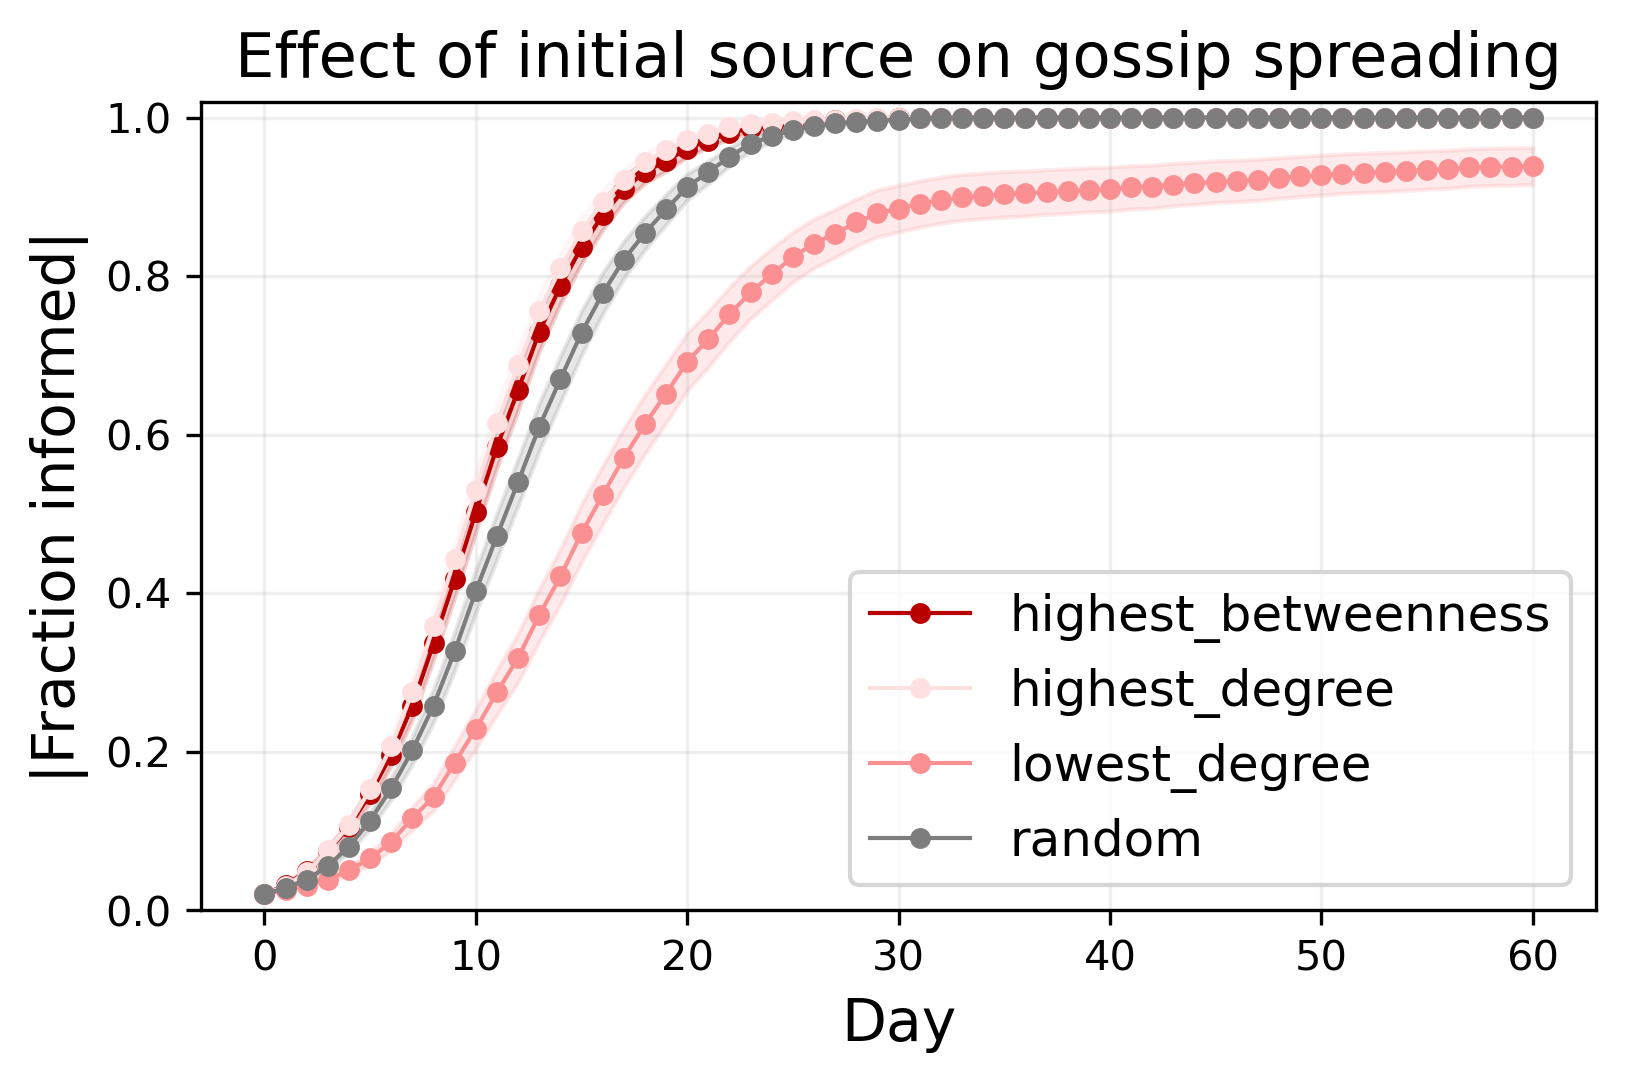

In [24]:
summary_start = summarize_spreading_curves(histories_start)

plot_static_vs_lunch_average_curves(
    summary_start,
    show_se_band=True,
    title="Effect of initial source on gossip spreading",
    colors=start_mode_colors,
    save_path="./figures/start_node_spreading_curves.pdf",
)

## Effect of table size
### 72 seats in the mensa

- table_size = 3  -> n_tables = 24
- table_size = 4  -> n_tables = 18
- table_size = 6  -> n_tables = 12
- table_size = 8  -> n_tables = 9
- table_size = 9  -> n_tables = 8
- table_size = 12 -> n_tables = 6

In [26]:
table_sizes = [3, 4, 6, 8, 9, 12]
total_chairs = 72

histories_table, t80_table = run_table_size_comparison(
    base_params=params,
    table_sizes=table_sizes,
    total_chairs=total_chairs,
    n_runs=100,
    max_days=60,
    threshold=0.8,
    start_mode="random",
    seed_start=3000,
)

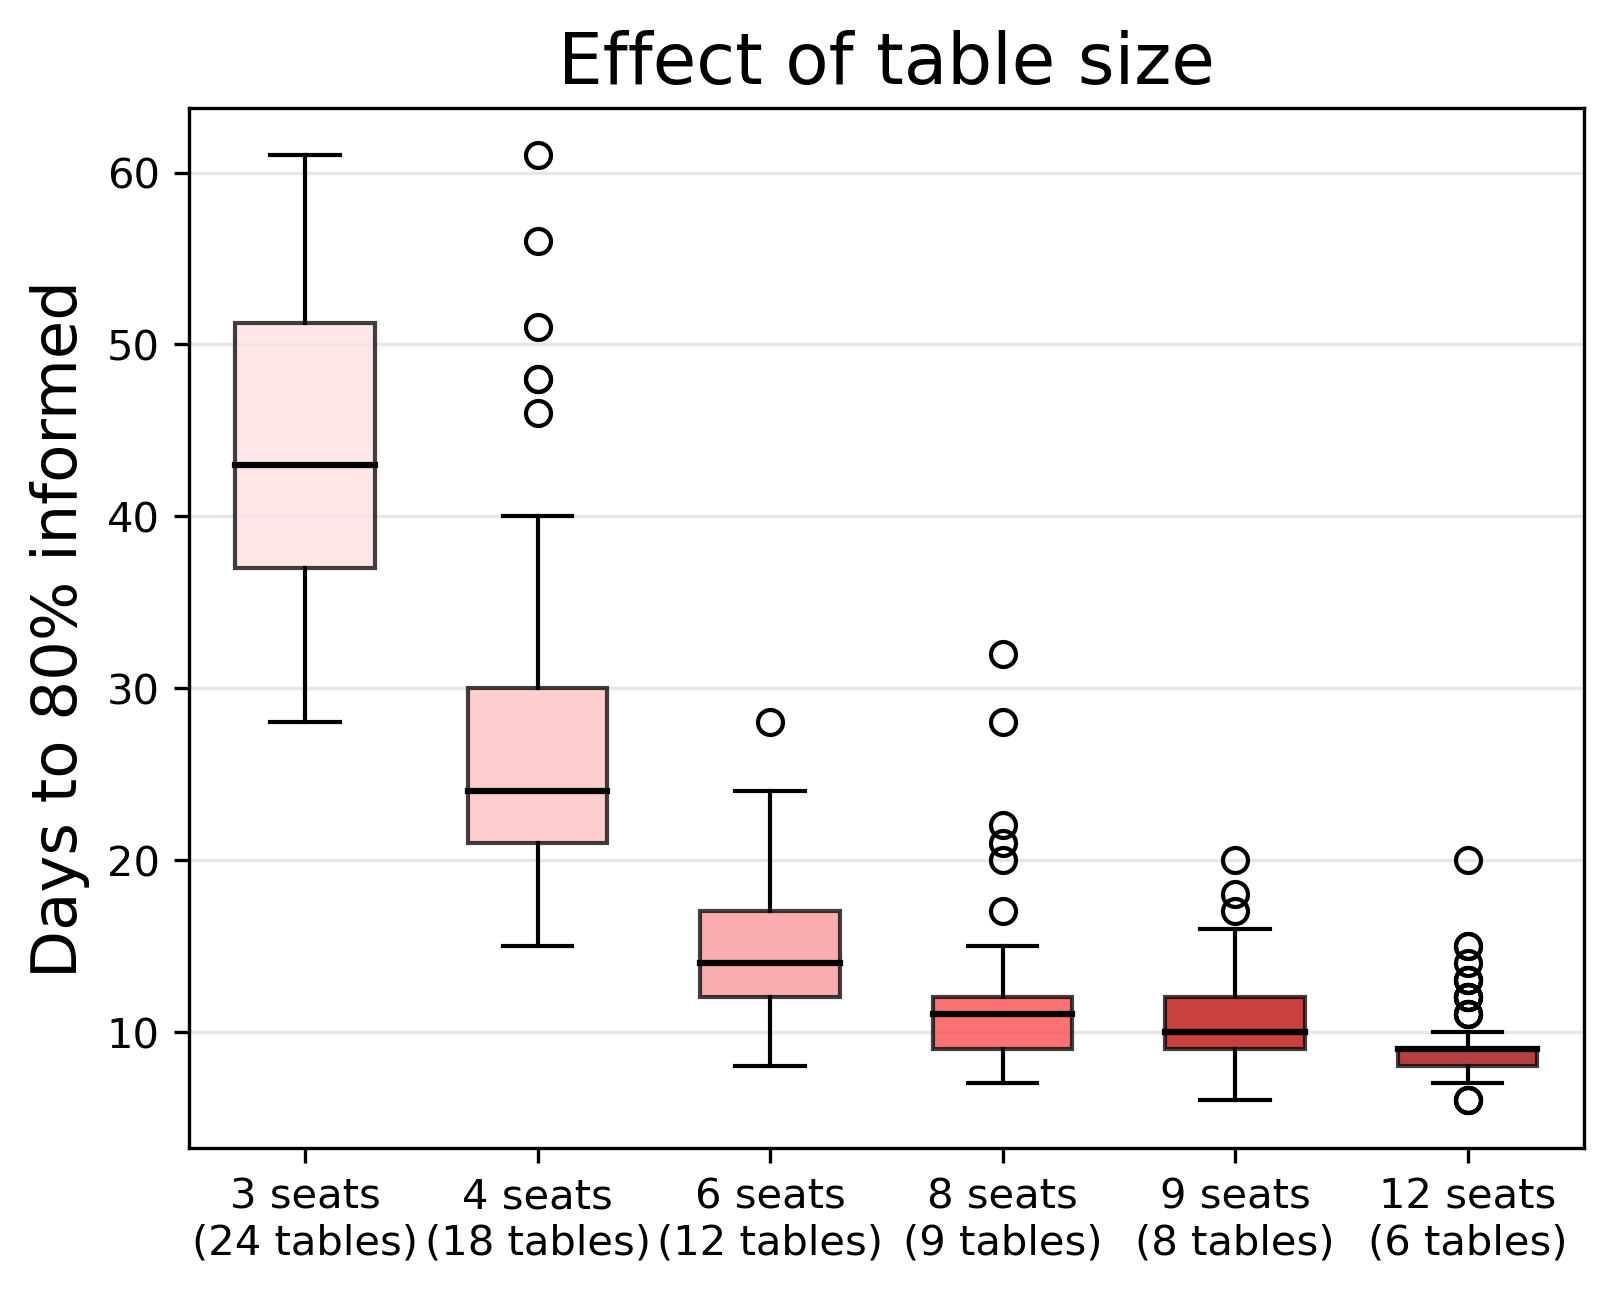

In [27]:
table_size_colors = {
    3: "#FFE0E1",
    4: "#FFBEBF",
    6: "#FA9092",
    8: "#FA4346",
    9: "#B80000",
    12: "#9E0000",
}

plot_table_size_threshold_boxplot(
    t_thresholds=t80_table,
    threshold=0.8, xlabel="",
    order=table_sizes, figsize=(6, 4.5),
    colors=table_size_colors,
    save_path="./figures/table_size_T80_boxplot.pdf",
)

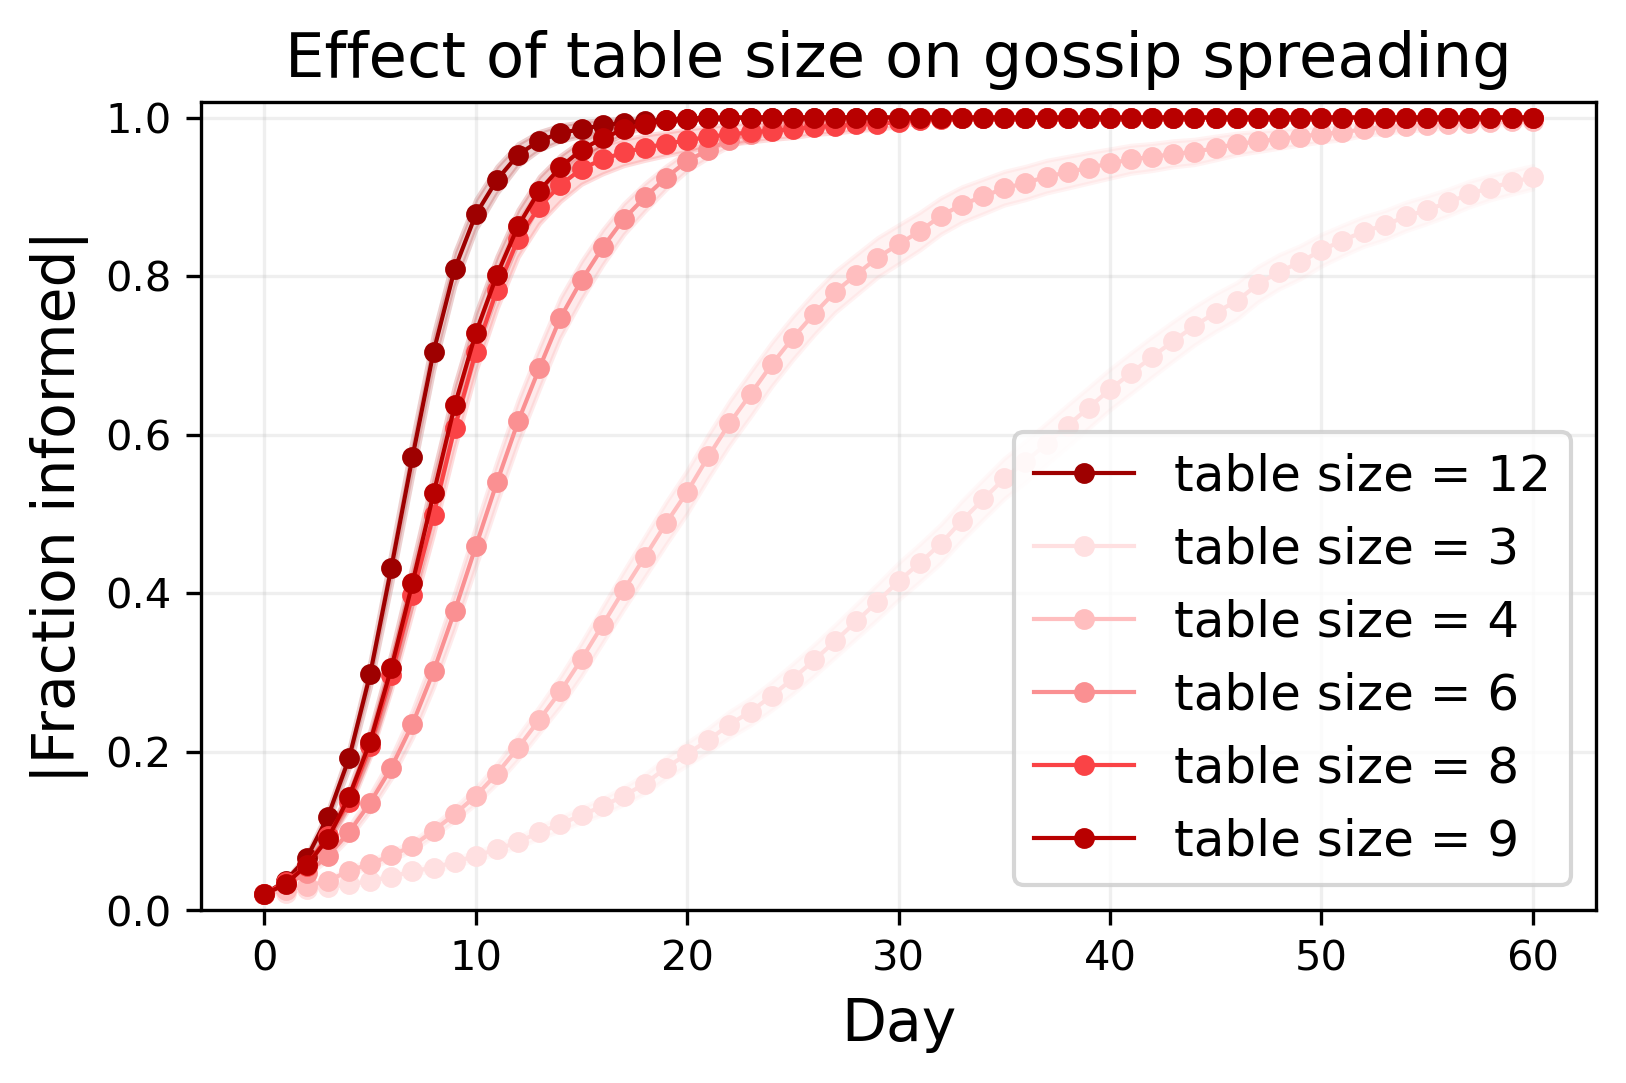

In [28]:
summary_table = summarize_spreading_curves(histories_table)

line_colors = {
    f"table size = {size}": color
    for size, color in table_size_colors.items()
}

plot_static_vs_lunch_average_curves(
    summary_table,
    show_se_band=True,
    title="Effect of table size on gossip spreading",
    colors=line_colors,
    save_path="./figures/table_size_spreading_curves.png",
)

## Effect of friend seating bias
- 0  = random seating
- 1  = weak preference for acquaintances
- 3  = moderate preference
- 6  = strong preference
- 10 = very strong preference

In [29]:
bias_values = [0, 1, 3, 6, 10]

histories_bias, t80_bias = run_friend_seating_bias_comparison(
    base_params=params,
    bias_values=bias_values,
    n_runs=100,
    max_days=60,
    threshold=0.8,
    start_mode="random",
    seed_start=4000,
)

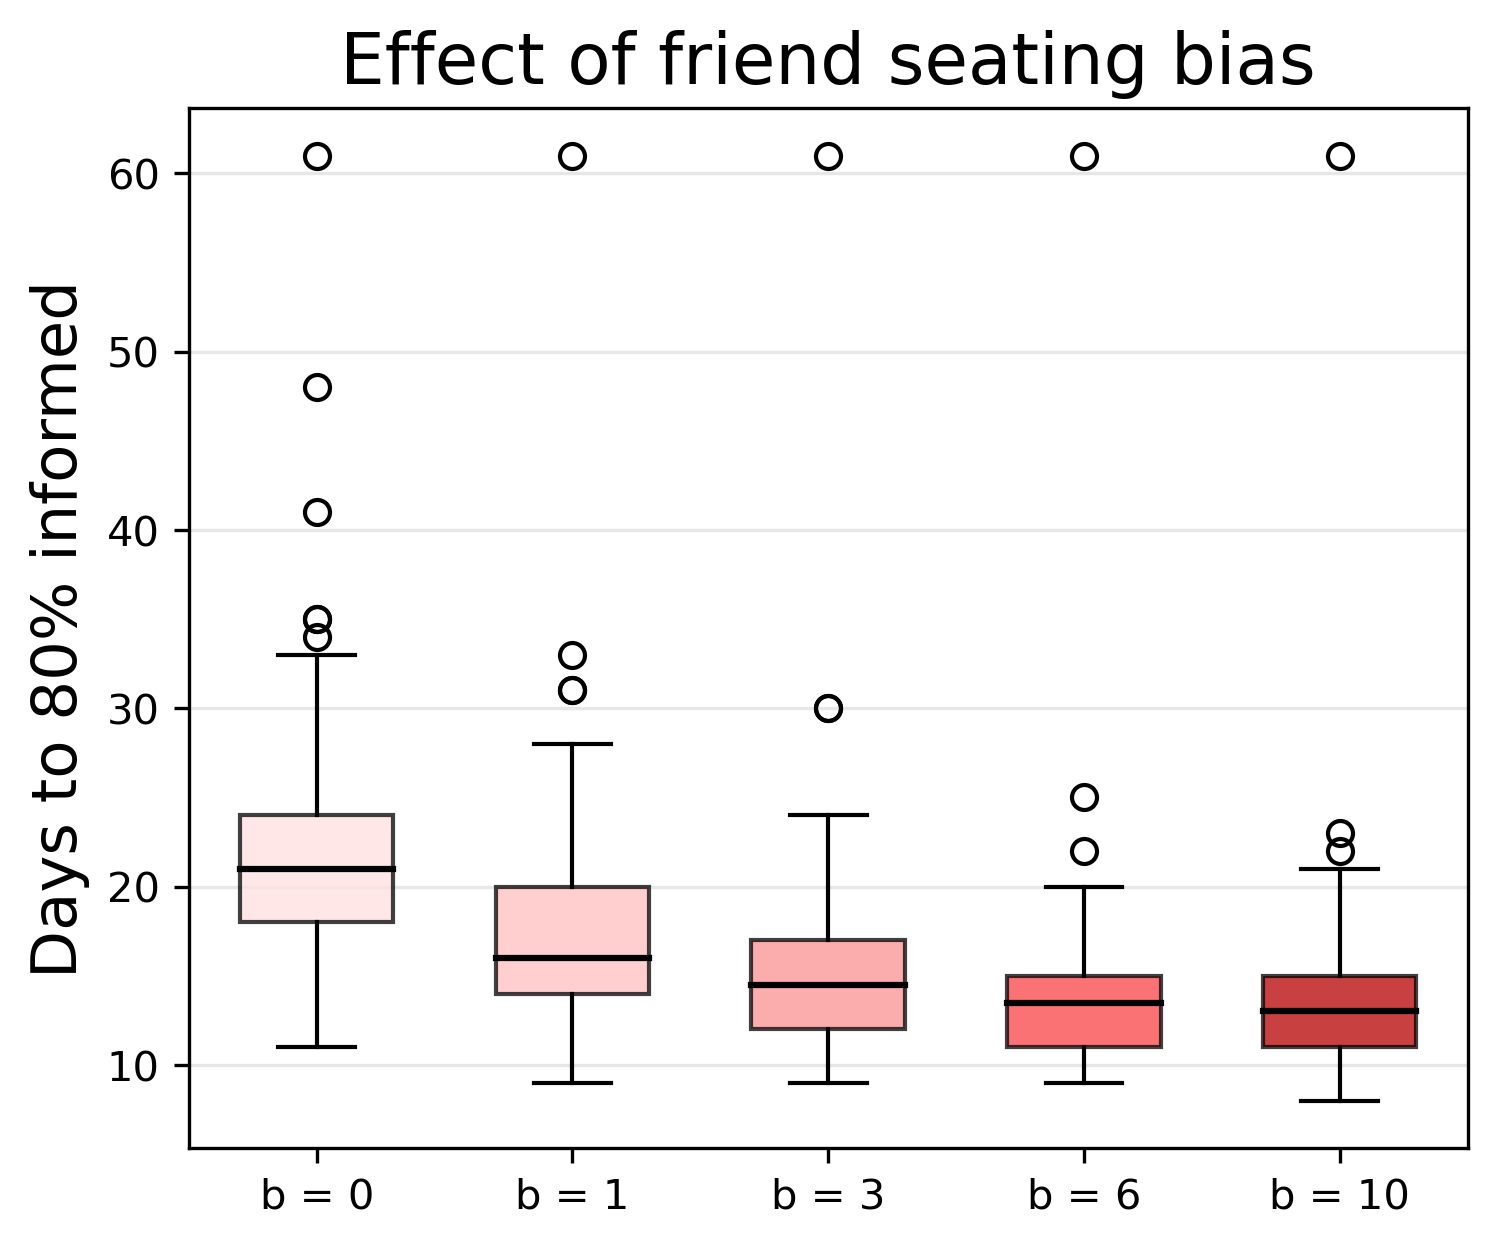

In [30]:
bias_colors = {
    0: "#FFE0E1",
    1: "#FFBEBF",
    3: "#FA9092",
    6: "#FA4346",
    10: "#B80000",
}

plot_friend_seating_bias_threshold_boxplot(
    t_thresholds=t80_bias,
    threshold=0.8,
    order=bias_values, figsize=(5.5, 4.5),
    colors=bias_colors, xlabel="",
    save_path="./figures/friend_seating_bias_T80_boxplot.pdf",
)

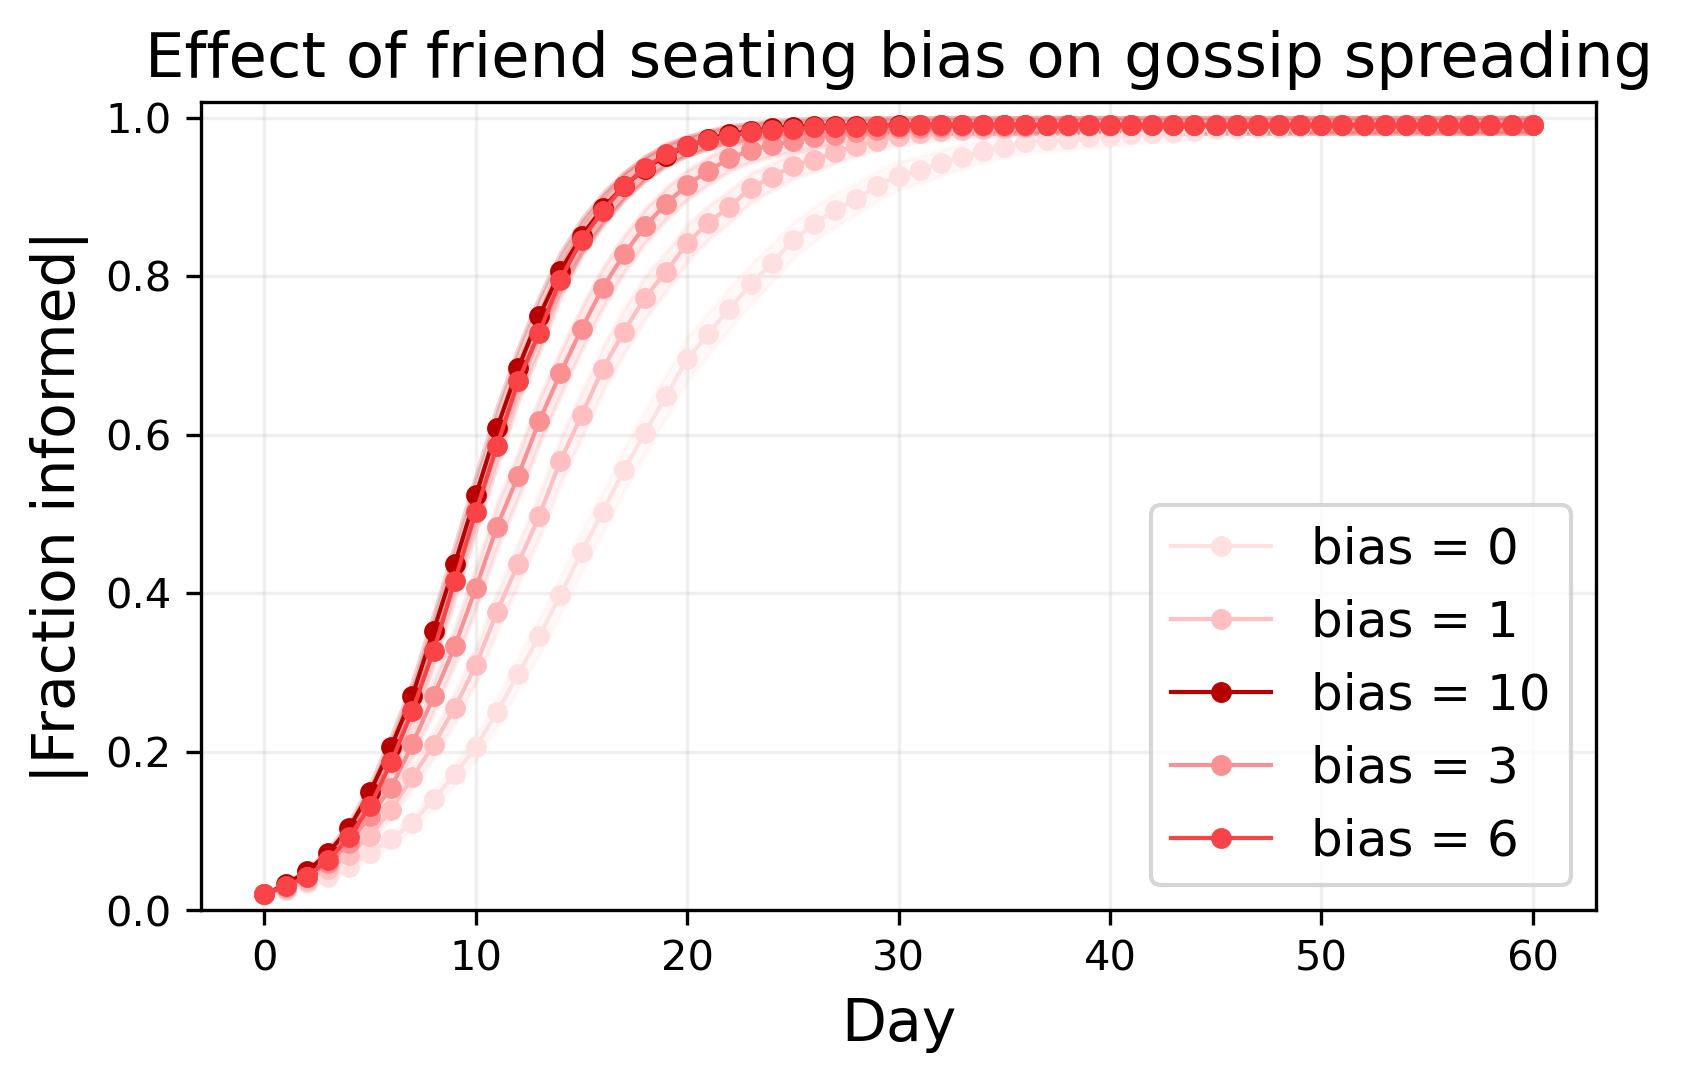

In [31]:
summary_bias = summarize_spreading_curves(histories_bias)

line_colors = {
    f"bias = {bias:g}": color
    for bias, color in bias_colors.items()
}

plot_static_vs_lunch_average_curves(
    summary_bias,
    show_se_band=True,
    title="Effect of friend seating bias on gossip spreading",
    colors=line_colors,
    save_path="./figures/friend_seating_bias_spreading_curves.png",
)

# Investigation of SIR model

- 0.00 = SI model, no one stops the gossip
- 0.02 = very slow decay
- 0.05 = slow decay
- 0.10 = faster decay
- 0.20 = very fast decay

In [32]:
stifling_prob_values = [0.00, 0.02, 0.05, 0.10, 0.20]

histories_sir, t80_sir = run_sir_stifling_comparison(
    base_params=params,
    stifling_prob_values=stifling_prob_values,
    n_runs=100,
    max_days=60,
    threshold=0.8,
    start_mode="random",
    seed_start=5000,
)

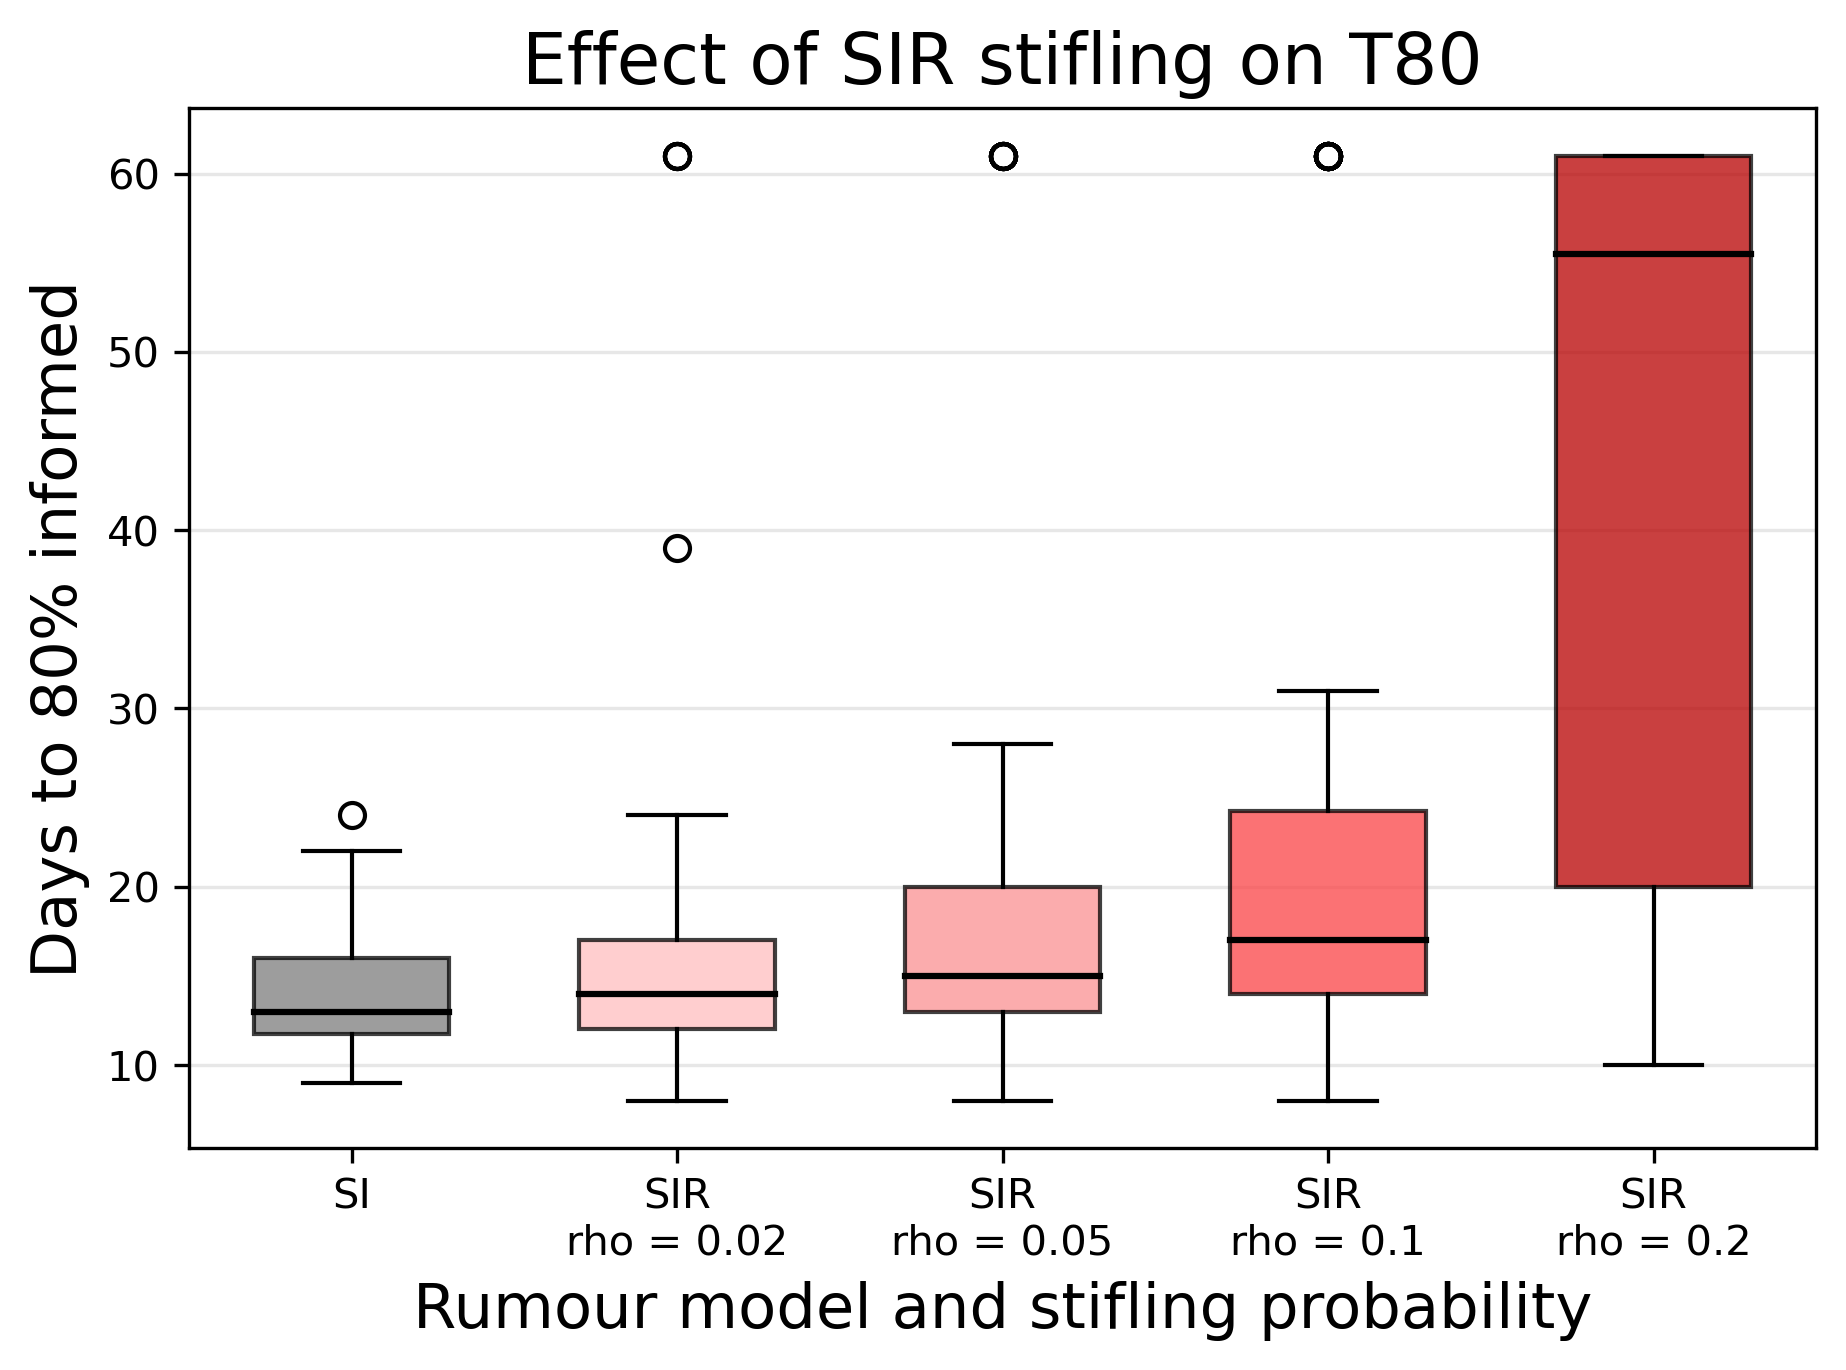

In [36]:
sir_colors = {
    0.00: "#7D7D7D",
    0.02: "#FFBEBF",
    0.05: "#FA9092",
    0.10: "#FA4346",
    0.20: "#B80000",
}

plot_sir_stifling_threshold_boxplot(
    t_thresholds=t80_sir,
    threshold=0.8,
    order=stifling_prob_values,
    colors=sir_colors,
    save_path="./figures/SIR_T80_boxplot.png",
)

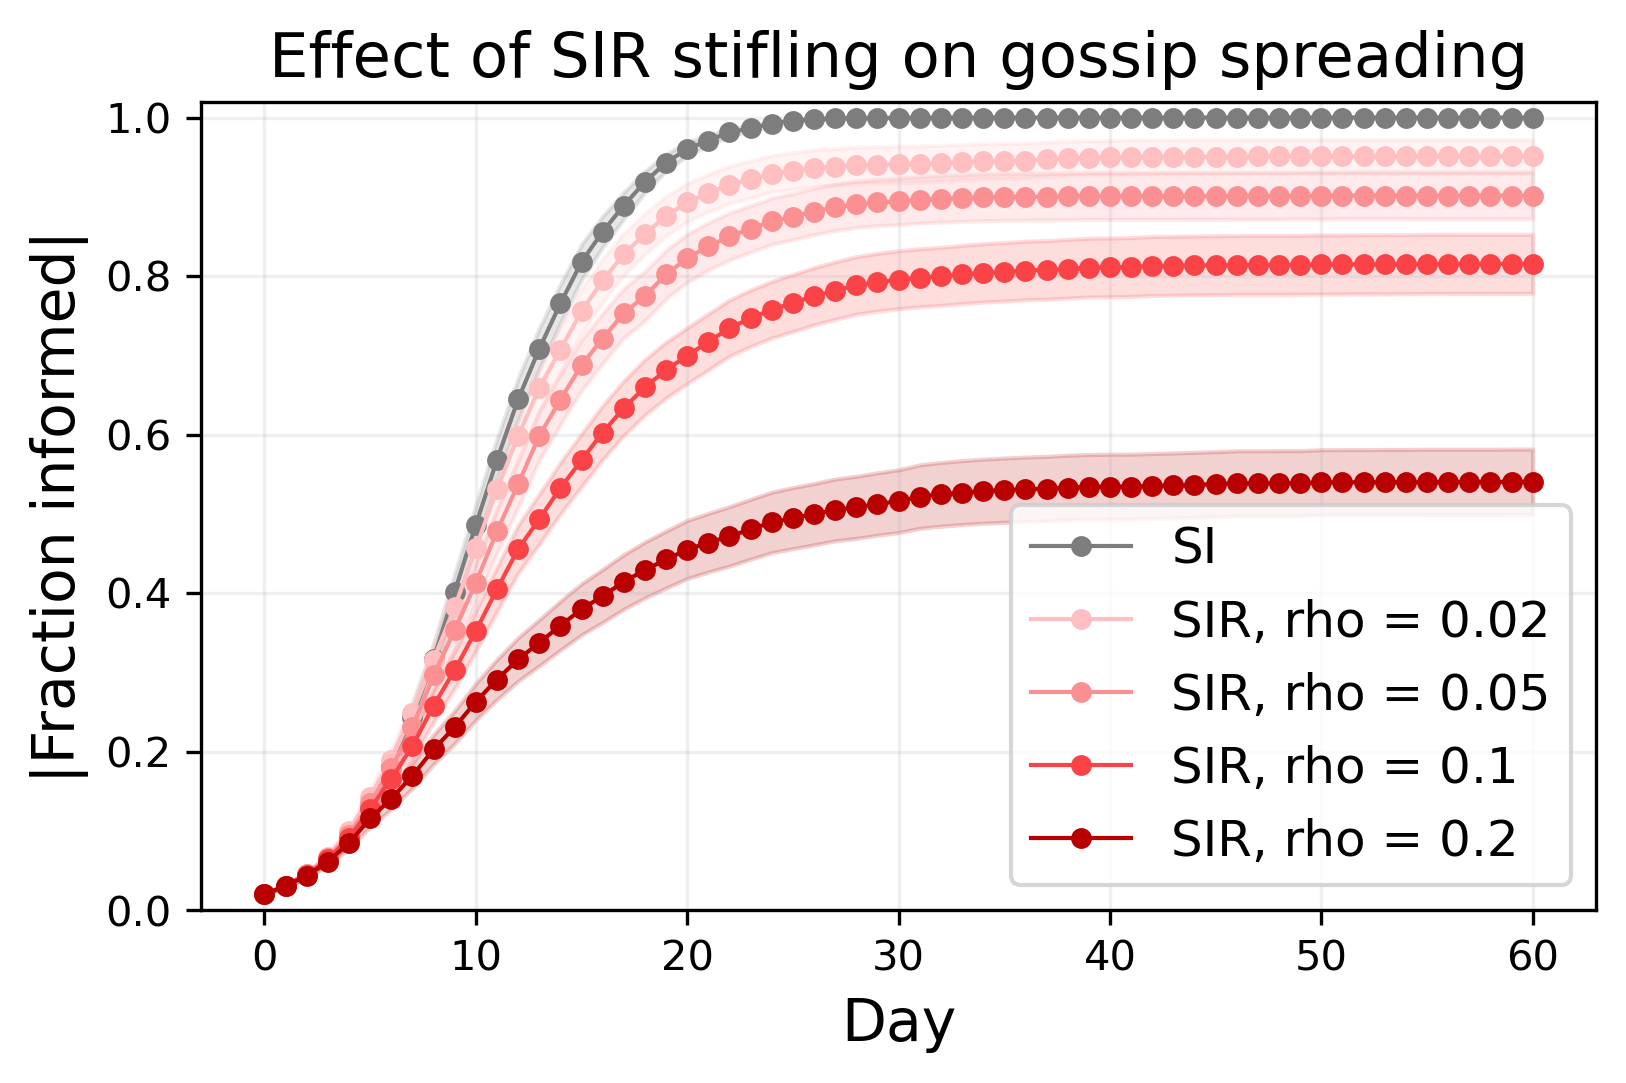

In [37]:
summary_sir = summarize_spreading_curves(histories_sir)

sir_line_colors = {
    "SI": sir_colors[0.00],
    "SIR, rho = 0.02": sir_colors[0.02],
    "SIR, rho = 0.05": sir_colors[0.05],
    "SIR, rho = 0.1": sir_colors[0.10],
    "SIR, rho = 0.2": sir_colors[0.20],
}

plot_static_vs_lunch_average_curves(
    summary_sir,
    show_se_band=True,
    title="Effect of SIR stifling on gossip spreading",
    colors=sir_line_colors,
    save_path="./figures/SIR_spreading_curves.pdf",
)

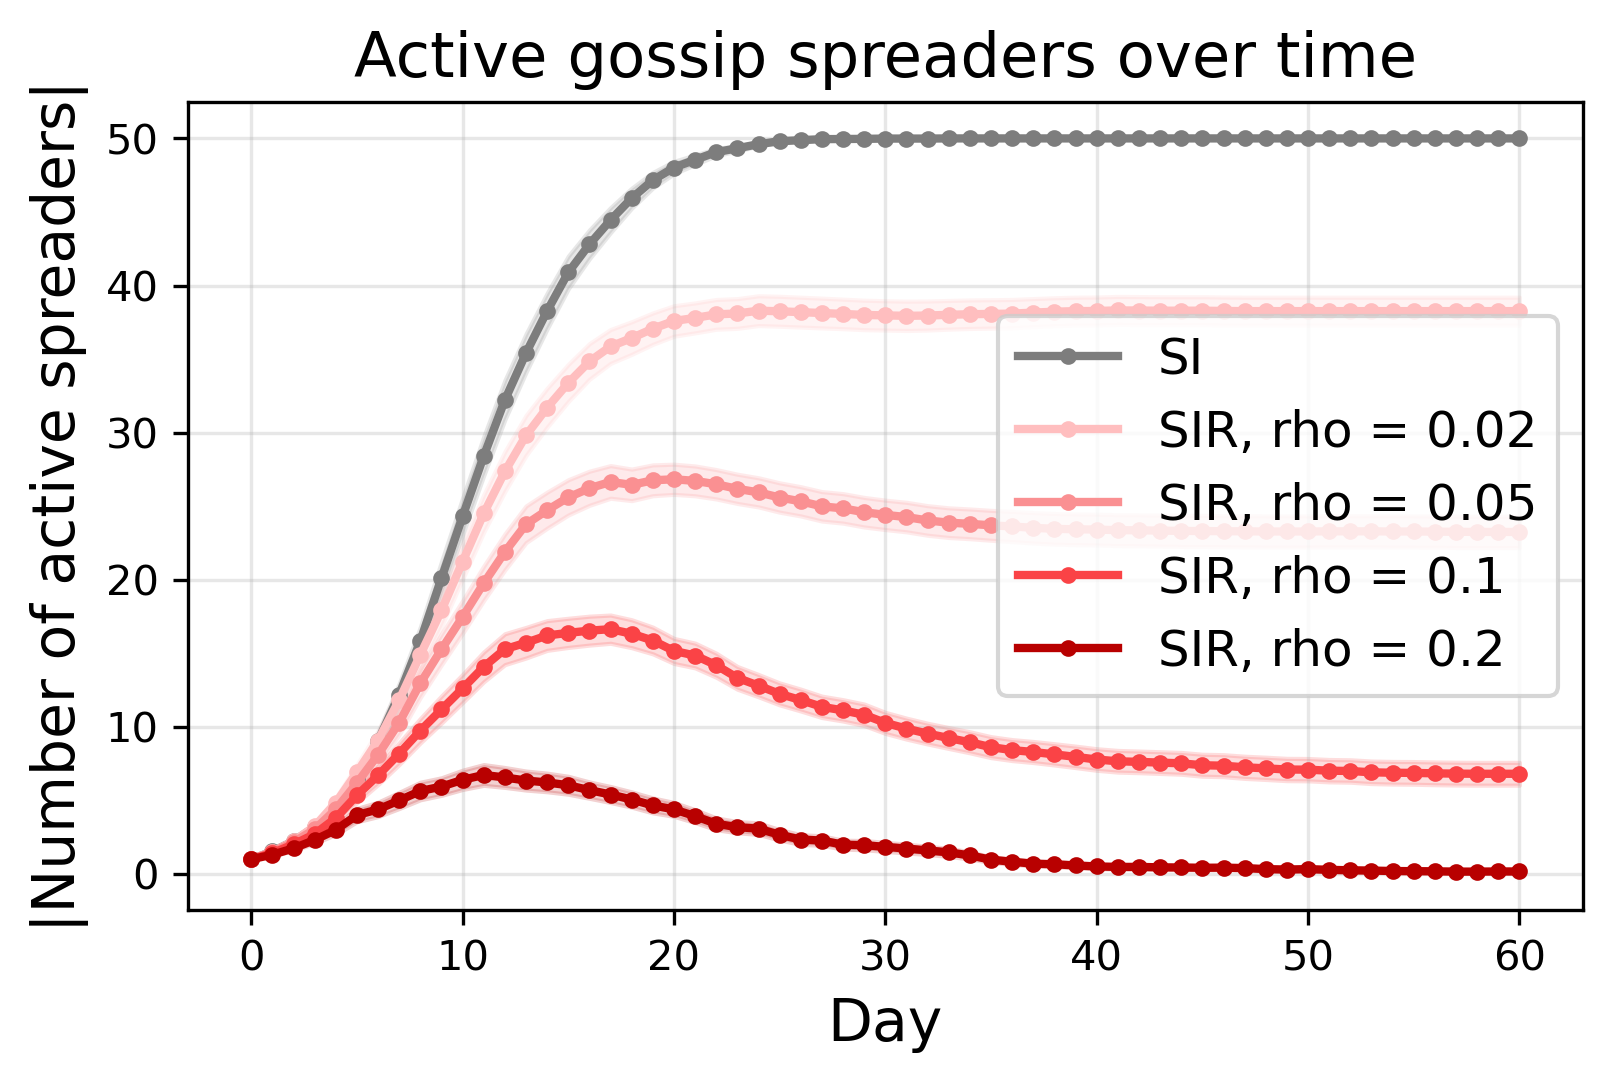

In [38]:
summary_active_sir = summarize_active_spreader_curves(histories_sir)

plot_active_spreader_curves(
    summary_active_sir,
    show_se_band=True,
    colors=sir_line_colors,
    save_path="./figures/SIR_active_spreaders.pdf",
)